# Turned-Down M1 Inner Edge: Intra- and Extra-Focal Donuts (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-10-09
**Last Modified:** 2026-10-09
**Status:** Complete
**Keywords:** turned-down edge, M1 figure, donut, intra-focal, extra-focal, camera hexapod, M2 hexapod, Kolmogorov, seeing, Rubin

## Description

Tests whether a turned-down figure at the inner edge of M1 makes the inner edge of the
intra-focal donut softer and that of the extra-focal donut sharper, as predicted in
`optics/docs/studies/intra_extra_phase_strip.md`.

The donuts are those of `optics_fresnel_hexapods_4mm_v1.ipynb`: Rubin design
prescription (`LSST_r.yaml`, 622 nm, on axis) with the camera and M2 both pistoned
−4 mm (intra-focal) or +4 mm (extra-focal).

1. **Edge model.** M1 is perturbed by an exponential roll-off at its inner edge
   (r = 2.558 m): a surface depression of 50 nm at the edge falling with a 5 cm
   e-folding scale. Its maximum surface slope is 1 µrad, which deflects reflected
   rays toward the axis by up to 2 µrad.
2. **Images.** Each side is traced with and without the edge, using the same 2×10⁸
   pupil samples, so the difference between the two images is free of shot noise
   except where rays move between pixels. Images are made geometric and with a 0.7″
   Kolmogorov kernel, in 10 µm pixels.
3. **Comparisons.** Intra and extra overlaid, each donut with and without the edge,
   and the width of the inner edge.

**Output:** figures in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/intra_extra_phase_strip.md`,
`optics_fresnel_hexapods_4mm_v1.ipynb`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-10-09 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Turned-down edge model](#model)
5. [Ray tracing](#trace)
6. [Intra and extra overlaid](#overlay)
7. [Each donut with and without the edge](#compare)
8. [Inner-edge widths](#widths)
9. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
prescription = 'LSST_r.yaml'   # batoid design prescription, r band
wavelength = 622e-9            # m
piston = 4e-3                  # m, camera and M2 piston magnitude (same sign)
seeing_fwhm = 0.7              # arcsec, Kolmogorov FWHM

tde_depth = 50e-9              # m, M1 surface depression at the inner edge
tde_width = 0.05               # m, e-folding scale of the roll-off
r_edge = 2.558                 # m, M1 inner clear-aperture radius

n_rays = 200_000_000           # rays per donut (same samples for every optic)
pixel = 10e-6                  # m, LSSTCam pixel
oversample = 5                 # sub-pixels per pixel for the convolution
npix = 740                     # pixels per stamp side (7.4 mm)
kernel_npix = 301              # kernel samples per side at pixel/oversample

dr_um = 2.0                    # um, radial annulus width
r_max_um = 3800.0              # um, outer radius of the radial profiles
inner_zoom_um = (1900, 2300)   # um, radius range of the inner-edge zoom
output_date = '20261009'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))
from common.utils import setup_plotting

import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import donut_seeing as ds
import batoid
import galsim

setup_plotting()
output_dir = _TOPIC / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
print('batoid', batoid.__version__, '| galsim', galsim.__version__)

batoid 0.8.1 | galsim 2.8.5


<a id='functions'></a>
## Helper Functions

In [3]:
r_edges_um = np.arange(0, r_max_um + 1e-9, dr_um)
r_centers_um = 0.5 * (r_edges_um[1:] + r_edges_um[:-1])


def ray_profile(counts):
    """Surface brightness from radial ray counts, int E 2 pi r dr = 1 (1/um^2)."""
    return counts / (np.pi * np.diff(r_edges_um**2)) / counts.sum()


def pixel_profile(image, scale_um):
    """Azimuthal mean of a centred stamp [y, x], normalised to int E 2 pi r dr = 1.

    Annuli are 5 um wide to average over the 10 um pixel grid.
    """
    edges = np.arange(0, r_max_um + 1e-9, 5.0)
    n = image.shape[0]
    c = (np.arange(n) - (n - 1) / 2) * scale_um
    X, Y = np.meshgrid(c, c)
    r = np.hypot(X, Y).ravel()
    tot, _ = np.histogram(r, edges, weights=image.ravel())
    cnt, _ = np.histogram(r, edges)
    rc = 0.5 * (edges[1:] + edges[:-1])
    prof = tot / np.maximum(cnt, 1) / scale_um**2
    return rc, prof / np.sum(prof * 2 * np.pi * rc * np.diff(edges))


def inner_edge_width(r, prof, lo=0.2, hi=0.8):
    """Radial distance (um) between the lo and hi crossings of the inner edge.

    Levels are fractions of the plateau, the median profile over the middle half of
    the annulus.
    """
    half = prof > 0.5 * prof.max()
    i0 = np.argmax(half)
    i1 = len(half) - 1 - np.argmax(half[::-1])
    plateau = np.median(prof[i0 + (i1 - i0) // 4:i1 - (i1 - i0) // 4])
    seg_r, seg_p = r[:(i0 + i1) // 2], prof[:(i0 + i1) // 2]

    def crossing(level):
        j = np.argmax(seg_p >= level)
        return np.interp(level, seg_p[j - 1:j + 1], seg_r[j - 1:j + 1])

    return crossing(hi * plateau) - crossing(lo * plateau), crossing(0.5 * plateau)

<a id='model'></a>
## 4. Turned-down edge model

The perturbation is added to the M1 surface sag (`withPerturbedSurface`), with
negative values away from the incoming light. The left panel shows the surface
profile; the right panel shows, for rays at a range of pupil radii, how far each ray
moves on the detector when the edge is added. Rays from the edge zone move toward
the axis by the same vector on both sides of focus: into the central hole of the
upright intra-focal image, and into the annulus of the inverted extra-focal image.

intra: maximum ray shift -20.4 um (negative y = toward the axis for intra, away from it for extra)
extra: maximum ray shift -20.3 um (negative y = toward the axis for intra, away from it for extra)


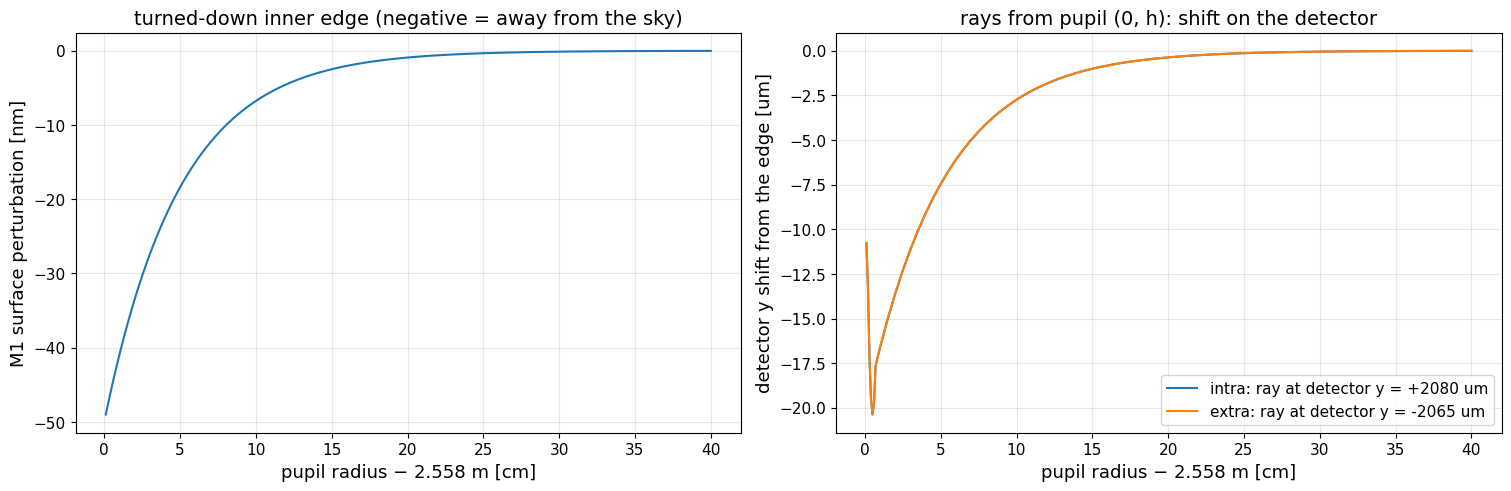

In [4]:
telescope = batoid.Optic.fromYaml(prescription)
tde = fd.turned_down_edge(tde_depth, tde_width, r_edge=r_edge)
optics = {}
for side, dz in (('intra', -piston), ('extra', piston)):
    base = fd.shift_hexapods(telescope, dz)
    optics[(side, 'design')] = base
    optics[(side, 'turned-down edge')] = base.withPerturbedSurface('M1', tde)

h = np.linspace(r_edge + 0.001, r_edge + 0.4, 400)   # m, pupil radius
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot((h - r_edge) * 100, -tde_depth * np.exp(-(h - r_edge) / tde_width) * 1e9)
axes[0].set_xlabel('pupil radius − 2.558 m [cm]')
axes[0].set_ylabel('M1 surface perturbation [nm]')
axes[0].set_title('turned-down inner edge (negative = away from the sky)')
shift = {}
for side in ('intra', 'extra'):
    y = []
    for kind in ('design', 'turned-down edge'):
        o = optics[(side, kind)]
        rv = batoid.RayVector.fromStop(np.zeros_like(h), h, optic=o,
                                       wavelength=wavelength, dirCos=fd.dircos(0, 0))
        o.trace(rv)
        y.append(rv.y - fd.chief_ray_point(o, wavelength)[1])
    shift[side] = (y[1] - y[0]) * 1e6
    axes[1].plot((h - r_edge) * 100, shift[side],
                 label=f'{side}: ray at detector y = {y[0][0]*1e6:+.0f} um')
axes[1].set_xlabel('pupil radius − 2.558 m [cm]')
axes[1].set_ylabel('detector y shift from the edge [um]')
axes[1].set_title('rays from pupil (0, h): shift on the detector')
axes[1].legend()
fig.savefig(output_dir / f'optics_fresnel_tde_model_{output_date}.png', dpi=120,
            bbox_inches='tight')
for side in shift:
    print(f"{side}: maximum ray shift {shift[side].min():.1f} um (negative y = "
          f"toward the axis for intra, away from it for extra)")

<a id='trace'></a>
## 5. Ray tracing

All four optics are traced with the same pupil samples (`seed=1`). Images are binned
at 2 µm and either summed into 10 µm pixels (geometric) or first convolved with the
0.7″ Kolmogorov kernel at the plate scale of each side.

In [5]:
psf = galsim.Kolmogorov(fwhm=seeing_fwhm)
res = {}
for key, o in optics.items():
    t0 = time.perf_counter()
    center = fd.chief_ray_point(o, wavelength)
    fine, counts, radii = fd.accumulate_donut(
        o, wavelength, n_rays, center, pixel / oversample, npix * oversample,
        r_edges_um * 1e-6, seed=1)
    kernel = ds.psf_kernel(psf, pixel / oversample, ds.plate_scale(o, wavelength),
                           npix=kernel_npix)
    see = ds.rebin(ds.smear(fine, kernel), oversample)
    rc, prof_see = pixel_profile(see, pixel * 1e6)
    res[key] = dict(geo=ds.rebin(fine, oversample), see=see,
                    prof_geo=ray_profile(counts), r_see=rc, prof_see=prof_see,
                    r_in=radii[0])
    print(f"{key[0]}, {key[1]:16s}: {counts.sum():.3e} rays, "
          f"{time.perf_counter()-t0:.0f} s")
    del fine

intra, design          : 9.824e+07 rays, 238 s


intra, turned-down edge: 9.824e+07 rays, 354 s


extra, design          : 9.824e+07 rays, 234 s


extra, turned-down edge: 9.824e+07 rays, 353 s


<a id='overlay'></a>
## 6. Intra and extra overlaid

Radial profiles of the two sides with the turned-down edge (solid) and the design
(dashed), geometric and with seeing, over the whole donut and zoomed on the inner
edge.

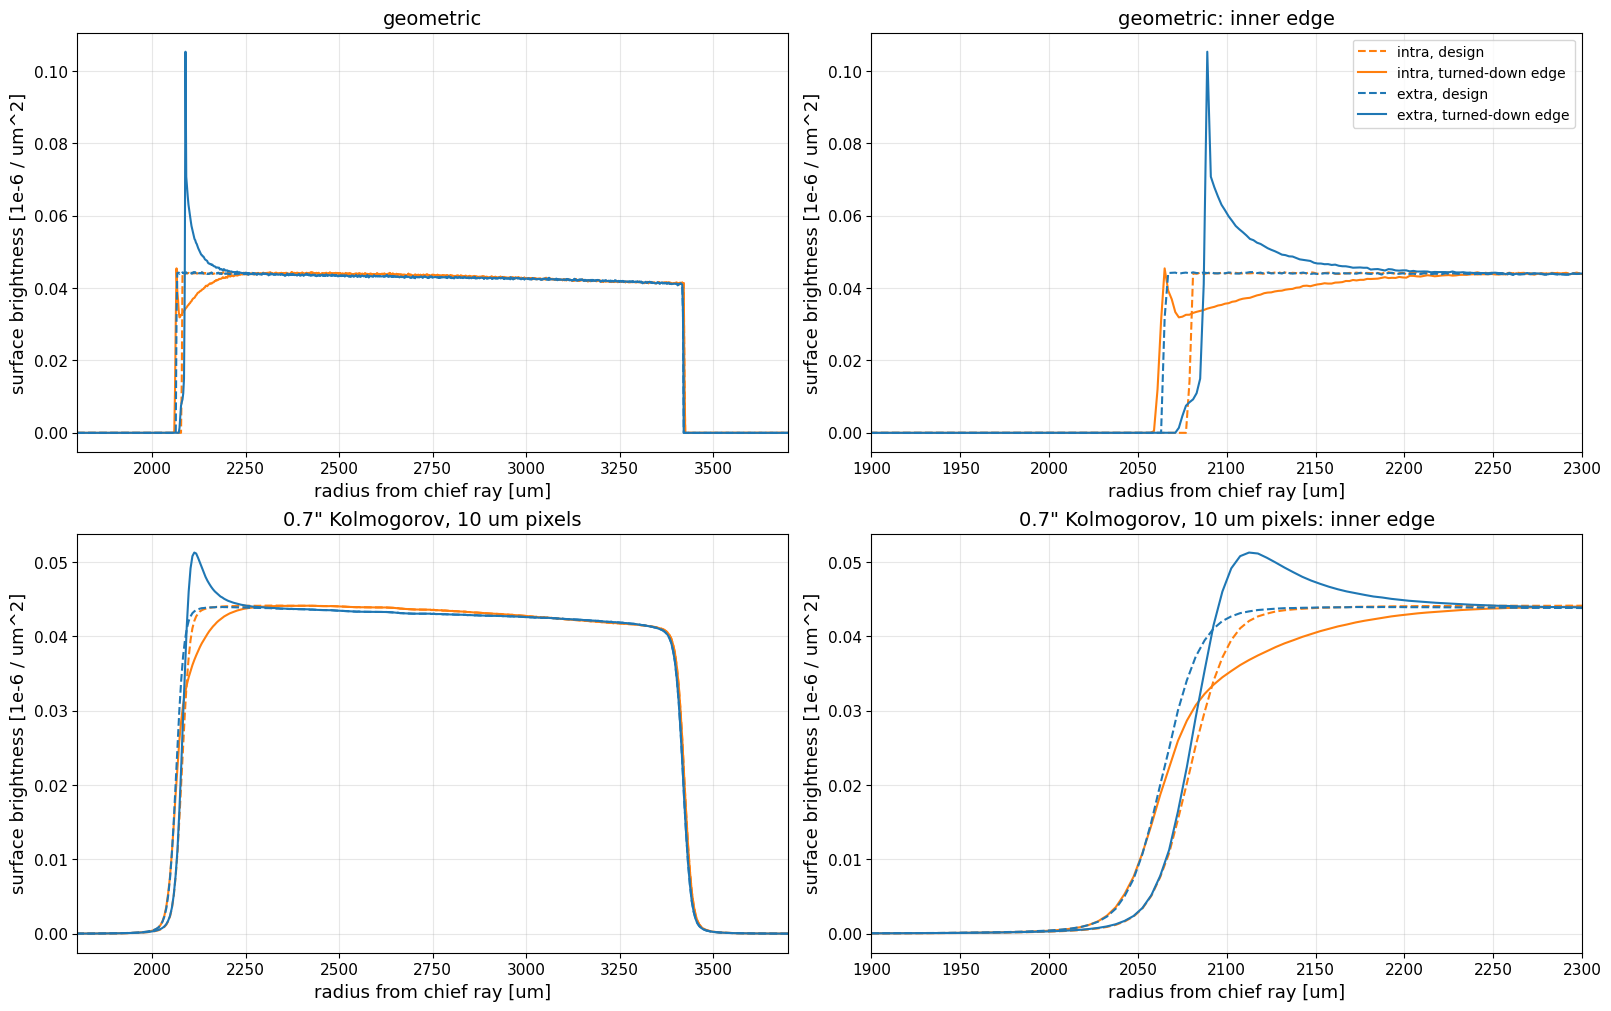

In [6]:
col = {'intra': 'C1', 'extra': 'C0'}
ls = {'design': '--', 'turned-down edge': '-'}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for (side, kind), r in res.items():
    lab = f'{side}, {kind}'
    for row, (x, y) in enumerate(((r_centers_um, r['prof_geo']),
                                  (r['r_see'], r['prof_see']))):
        for col_i in (0, 1):
            axes[row, col_i].plot(x, y * 1e6, ls[kind], color=col[side], label=lab)
for row, title in enumerate(('geometric', '0.7" Kolmogorov, 10 um pixels')):
    axes[row, 0].set_xlim(1800, 3700)
    axes[row, 1].set_xlim(*inner_zoom_um)
    axes[row, 0].set_title(title)
    axes[row, 1].set_title(f'{title}: inner edge')
    for a in axes[row]:
        a.set_xlabel('radius from chief ray [um]')
        a.set_ylabel('surface brightness [1e-6 / um^2]')
axes[0, 1].legend(fontsize=10)
fig.savefig(output_dir / f'optics_fresnel_tde_overlay_{output_date}.png', dpi=120,
            bbox_inches='tight')

<a id='compare'></a>
## 7. Each donut with and without the edge

Top: inner-edge profiles with and without the turned-down edge, for each side.
Bottom: the image difference (turned-down edge − design) with seeing, as a fraction
of the design peak pixel, in a 1.2 mm box centred on the inner edge at the top of
the donut.

intra: sum |turned-down edge - design| (seeing) = 0.0107 of total flux
extra: sum |turned-down edge - design| (seeing) = 0.0124 of total flux


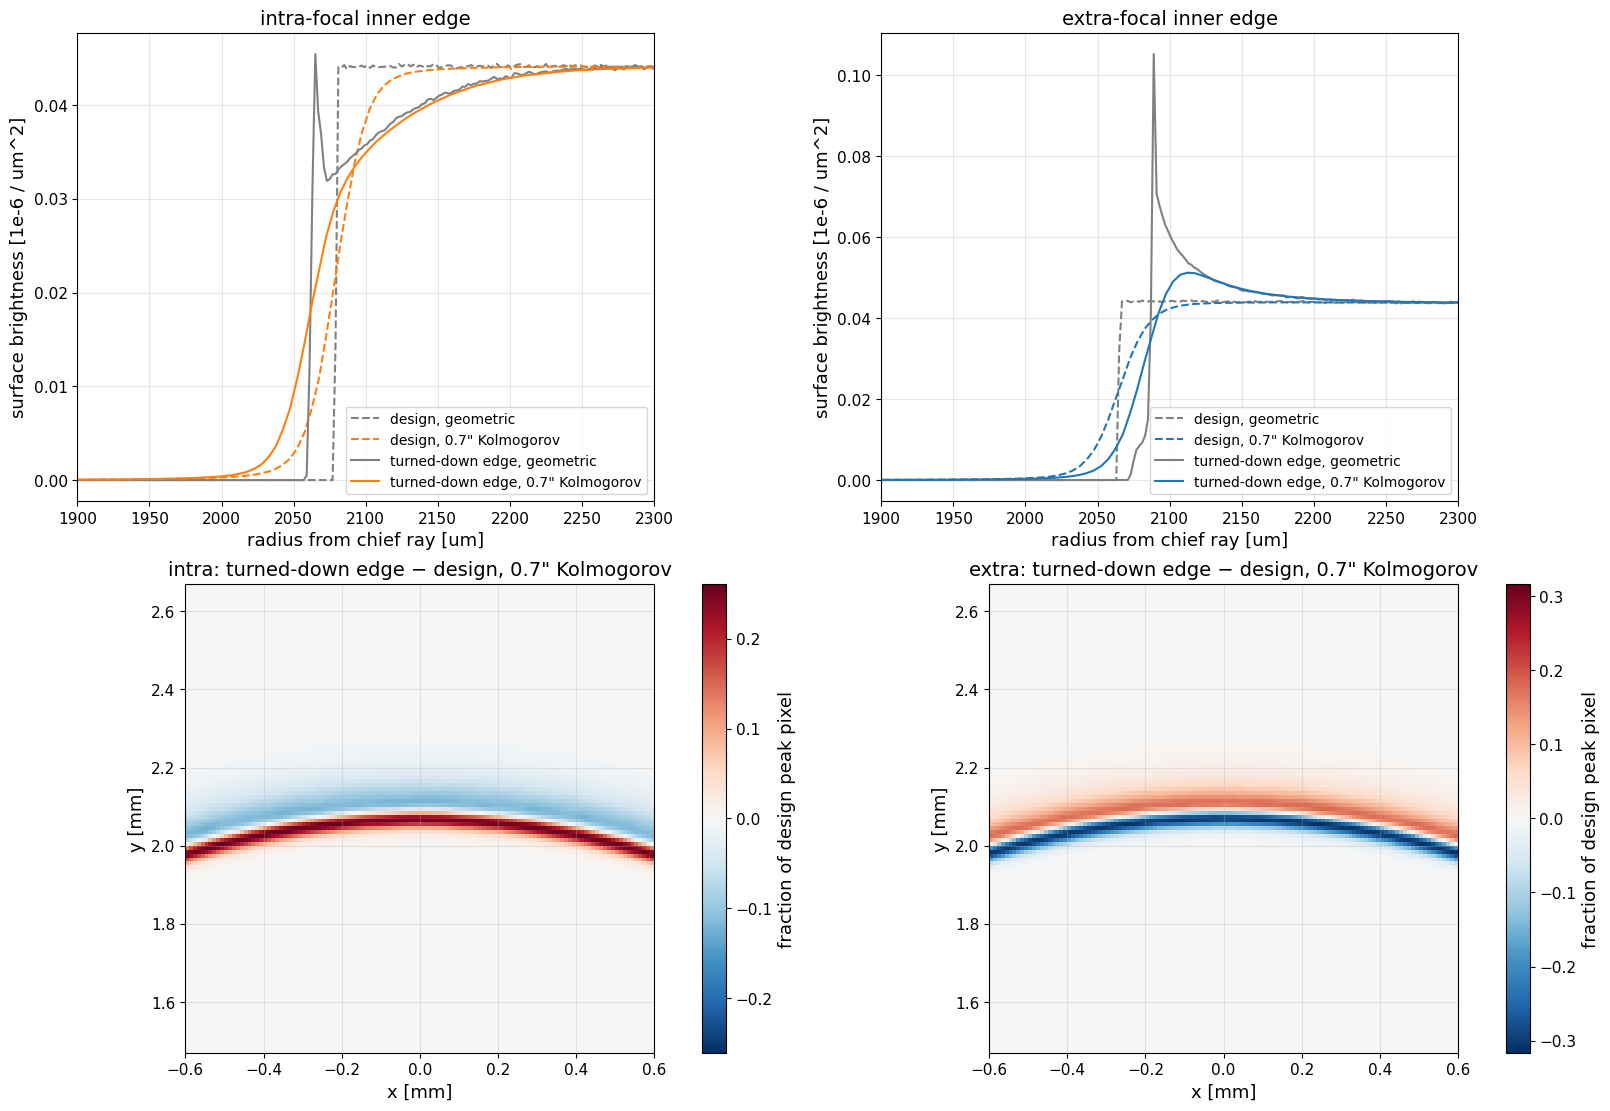

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for i, side in enumerate(('intra', 'extra')):
    a = axes[0, i]
    for kind in ('design', 'turned-down edge'):
        r = res[(side, kind)]
        a.plot(r_centers_um, r['prof_geo'] * 1e6, ls[kind], color='0.5',
               label=f'{kind}, geometric')
        a.plot(r['r_see'], r['prof_see'] * 1e6, ls[kind], color=col[side],
               label=f'{kind}, 0.7" Kolmogorov')
    a.set_xlim(*inner_zoom_um)
    a.set_xlabel('radius from chief ray [um]')
    a.set_ylabel('surface brightness [1e-6 / um^2]')
    a.set_title(f'{side}-focal inner edge')
    a.legend(fontsize=10)

    d = res[(side, 'turned-down edge')]['see'] - res[(side, 'design')]['see']
    d = d / res[(side, 'design')]['see'].max()
    c0 = npix // 2
    yc = c0 + int(round(2070e-6 / pixel))
    box = d[yc - 60:yc + 60, c0 - 60:c0 + 60]
    lim = np.max(np.abs(box))
    ext = np.array([-60, 60, yc - c0 - 60, yc - c0 + 60]) * pixel * 1e3
    im = axes[1, i].imshow(box, origin='lower', extent=ext, cmap='RdBu_r',
                           vmin=-lim, vmax=lim)
    axes[1, i].set_title(f'{side}: turned-down edge − design, 0.7" Kolmogorov')
    axes[1, i].set_xlabel('x [mm]')
    axes[1, i].set_ylabel('y [mm]')
    fig.colorbar(im, ax=axes[1, i], label='fraction of design peak pixel')
    print(f"{side}: sum |turned-down edge - design| (seeing) = "
          f"{np.abs(d).sum() * res[(side, 'design')]['see'].max():.4f} of total flux")
fig.savefig(output_dir / f'optics_fresnel_tde_compare_{output_date}.png', dpi=120,
            bbox_inches='tight')

<a id='widths'></a>
## 8. Inner-edge widths

Width of the inner edge between 20% and 80% of the plateau, and the radius of the
50% point, from the seeing profiles. The last column converts the quadrature
difference from the design on the same side into an angle,
√(w² − w_design²) / plate scale. This is an indicator of the extra blur only; the
Danish kernel is fitted to the whole donut.

In [8]:
print(f"{'donut':34s} {'20-80% width [um]':>18s} {'50% radius [um]':>16s} "
      f"{'extra blur [arcsec]':>20s}")
widths = {}
for (side, kind), r in res.items():
    widths[(side, kind)] = inner_edge_width(r['r_see'], r['prof_see'])
for (side, kind), (w, r50) in widths.items():
    w0 = widths[(side, 'design')][0]
    plate_um = ds.plate_scale(optics[(side, kind)], wavelength) * ds.ARCSEC * 1e6
    extra = np.sign(w - w0) * np.sqrt(abs(w**2 - w0**2)) / plate_um
    print(f"{side + ', ' + kind:34s} {w:18.2f} {r50:16.2f} {extra:20.3f}")

donut                               20-80% width [um]  50% radius [um]  extra blur [arcsec]
intra, design                                   29.62          2079.04                0.000
intra, turned-down edge                         50.52          2066.76                0.818
extra, design                                   28.69          2064.04                0.000
extra, turned-down edge                         23.01          2076.75               -0.343


<a id='conclusions'></a>
## 9. Conclusions

Monochromatic (622 nm), on axis, geometric optics, camera and M2 both pistoned ∓4 mm,
turned-down M1 inner edge 50 nm deep with a 5 cm e-folding scale. Numbers are from
this run.

- **The predicted sign holds.** The edge deflects inner-edge rays by up to 20.4 µm
  toward the axis on the detector, the same vector on both sides. The intra-focal
  inner edge becomes softer and the extra-focal inner edge sharper.
- **Inner-edge width (20–80% of plateau, with 0.7″ seeing):** intra 29.6 → 50.5 µm,
  extra 28.7 → 23.0 µm. As a quadrature difference from the design, that is +0.82″
  of extra blur intra-focal and −0.34″ (sharper) extra-focal. The observed intra −
  extra difference in the Danish kernel is about 0.41″ in quadrature, so this edge is
  stronger than needed; the Danish kernel also depends on the outer edge.
- **Profile shape.** At 8 mm equivalent defocus the 5 cm edge zone maps to about
  41 µm on the detector, comparable to the 20 µm ray shift. Intra-focal, the zone is
  stretched into a dim ramp about 150 µm wide; extra-focal, it is compressed into a
  bright rim peaking at 2.4 times the plateau (geometric) or 1.16 times with seeing
  (dimensionless ratios of surface brightness).
- **Edge position.** The 50% point of the inner edge moves 12.3 µm inward intra-focal
  and 12.7 µm outward extra-focal. A donut fit would absorb part of this as
  Zernike offsets of opposite sign on the two sides.
- **Flux moved:** Σ|turned-down − design| = 1.1% (intra) and 1.2% (extra) of total
  flux with seeing.
- **Model detail.** The bicubic surface smooths the slope discontinuity at the edge
  itself, so the outermost ~1 cm of the zone is deflected less than its neighbours;
  this makes the small spike at the start of the intra-focal geometric ramp.

Open next steps: fit these stamps with Danish to get the change in fitted kernel and
Zernike offsets; scan depth and width; add the outer edge; repeat at the 1.5 mm CWFS
defocus, where the edge zone maps to only about 8 µm.